In [1]:
import pickle
import behave_ana
import pandas as pd
import os
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
from scipy.stats import zscore,entropy
from scipy.signal import find_peaks
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

try:
    if __IPYTHON__:
        get_ipython().run_line_magic('load_ext', 'autoreload')
        get_ipython().run_line_magic('autoreload', '2')
except NameError:
    pass


In [ ]:
from pathlib import Path
path = "/home/zyyk78/HDD/zyyk78/MPtest/B07"
path = Path(path)
pkl_files = list(path.rglob("*.pkl"))
for file in pkl_files:
    print(file)

**把pkl路径弄到excel里面,然后把想分析的那一堆copy下就行了**

In [16]:
# 从剪贴板读取Excel复制的数据（自动检测分隔符）
df = pd.read_clipboard(header=None)  
# 转换为列表（每行一个子列表）
matches = df.values.tolist()  
print(matches)

data_collect = []
for pkl_path in matches:
    with open(pkl_path[0],"rb") as pkl_f:
        Event=pickle.load(pkl_f)
        long_event=['MinT','Blackhole']
        ignore_list=['MinS','CamT','LickL','LickR','tMod']
        eve_list=behave_ana.sort_events(Event,ignore_list=ignore_list,long_event=long_event)
        date_info=os.path.basename(pkl_path[0])
        date_info=str.split(date_info,'_')[0]
        try:
            _,_,tot_rew=behave_ana.reward_rate(Event)
        except:
            tot_rew=0
        if Event['ModL']['Time_S']==[] and Event['ModR']['Time_S']==[]:
            tot_acc=0
            print(date_info)
            print(len(Event['SlnL']['Time_S'])+len(Event['ROmL']['Time_S']))
            print(len(Event['SlnR']['Time_S'])+len(Event['ROmR']['Time_S']))
        else:
            _,_,tot_acc=behave_ana.accuracy_rate(eve_list)

        all_data={
            'date':date_info,
            'tot_rew':tot_rew,
            'tot_acc':tot_acc,
            'eve_list':eve_list
        }
        
        data_collect.append(all_data)
        
#data_collect.sort(key = lambda i : int(i['date']))

[['/home/zyyk78/HDD/zyyk78/MPtest/B04/20250725T7_00.pkl']]


In [5]:
for data in data_collect:
    print(data['tot_rew'])

0.6448
0.7137870855148342
0.5782608695652174
0.6283783783783784
0.6443661971830986
0.6672185430463576
0.7012089810017271
0.612141652613828
0.6496350364963503


In [6]:
A_sl=[]
A_err=[]
A_lick_rate=[]
for data in data_collect:
    eve_list=data['eve_list']
    lat_data = behave_ana.get_switching_latency(eve_list)
    A_sl.append(sum([i[0] for i in lat_data])/len(lat_data))
    A_err.append(sum([(len(i)-1)/2 for i in lat_data])/len(lat_data))
    lick_event = [ i for i in eve_list if i[1] in ['ROmL','ROmR','SlnL','SlnR'] ]
    A_lick_rate.append( (lick_event[-1][0] - lick_event[0][0]) /  (len(lick_event) * 50000) )

In [9]:
for i in A_err:
    print(i)

0.5666666666666667
0.38235294117647056
0.7857142857142857
1.7857142857142858
1.1923076923076923
0.6470588235294118
0.4166666666666667
0.9545454545454546
0.28125


In [32]:
# 从剪贴板读取Excel复制的数据（自动检测分隔符）
df = pd.read_clipboard(header=None)  
# 转换为列表（每行一个子列表）
data_list = df.values.tolist()  
data_0 = data_list[0]
with open(data_0[0],"rb") as pkl_f:
    Event=pickle.load(pkl_f)

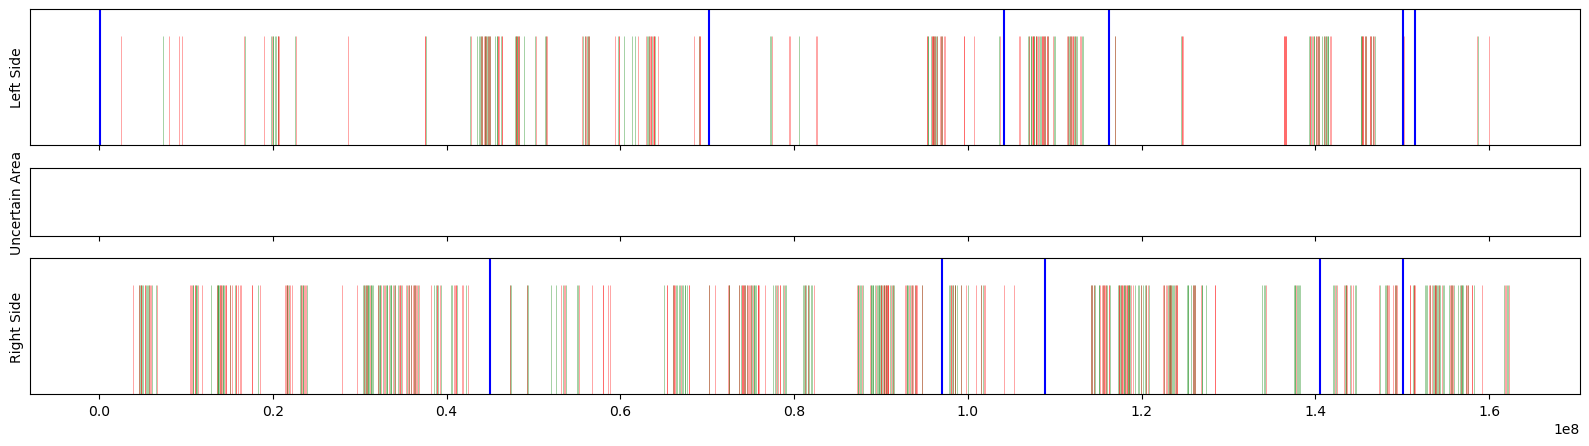

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax1_5, ax2) = plt.subplots(3, 1, figsize=(20, 5), 
                                   gridspec_kw={'height_ratios': [2 , 1 , 2]},sharex=True,)
sns.rugplot(Event['SlnL']['Time_S'] , ax=ax1, height=0.8, linewidth=0.5, color='green',alpha=0.5)
sns.rugplot(Event['SlnR']['Time_S'] , ax=ax2, height=0.8, linewidth=0.5, color='green',alpha=0.5)
sns.rugplot(Event['ROmL']['Time_S'] , ax=ax1, height=0.8, linewidth=0.5, color='red',alpha=0.5)
sns.rugplot(Event['ROmR']['Time_S'] , ax=ax2, height=0.8, linewidth=0.5, color='red',alpha=0.5)
sns.rugplot(Event['ModL']['Time_S'] , ax=ax1, height=1, linewidth=1.5, color='blue')
sns.rugplot(Event['ModR']['Time_S'] , ax=ax2, height=1, linewidth=1.5, color='blue')

if 'Blackhole' in Event:
    for i in range(len(Event['Blackhole']['Time_S'])):
        ax1_5.fill_betweenx(y=[-0.5, 0.5], x1 = Event['Blackhole']['Time_S'][i], x2=Event['Blackhole']['Time_E'][i],color='red')
ax1.set_yticks([])
ax1.set_ylabel('Left Side')
ax2.set_yticks([])
ax2.set_ylabel('Right Side')
ax1_5.set_yticks([])
ax1_5.set_ylabel('Uncertain Area')
plt.show()

In [ ]:
fig,ax_acc=plt.subplots()
acc_list=[]

In [ ]:
acc=np.array([i['tot_acc'] for i in data_collect])
acc_list.append(acc)
ax_acc.plot(acc)
display(fig)

In [ ]:
x=[1,2,3]
y1=[5.94,4.29,5.75]
y2=[6.45,10.2,5.15]
y3=[5.06,13.13,4.5]
plt.plot(x,y1,color='red',marker='o')
plt.plot(x,y2,color='blue',marker='o')
plt.plot(x,y3,color='green',marker='o')
plt.errorbar(x=[0],y=[7.97],yerr=[2.51],capsize=5,fmt='-o')

plt.title('Effect of Prefeeding, n=3\n1g+30min rest')
# plt.title('Effect of Running, n=3\n50min+10min rest')    
plt.xticks([0,1,2,3],['Training Average','1','2','3'])
plt.xlabel('Session')
plt.ylabel('Switching Latency (Trials)')

In [ ]:

data = np.array([
    [0.788213628, 0.650470219],
    [0.761061947, 0.729411765],
    [0.636645963, 0.590841949],
    [0.758318739, 0.678160920],
    [0.760638298, 0.654028436]
])

# 转置为列为 series
data = data.T  # shape: (2, 5)

plt.figure(figsize=(6, 4))

for i, series in enumerate(data):
    x = np.arange(len(series))
    
    # 前两个点灰色
    plt.plot(x[:3], series[:3], color='gray', linewidth=2, marker='o')
    
    # 后续点彩色（从点2开始连接到最后）
    plt.plot(x[2:], series[2:], linewidth=2, marker='o')
    

plt.xticks(range(len(data[0])), ['T','T','R','R','R'])
plt.ylabel('Accuracy')
plt.title(f'Effect of Running, n=2 \n 50min +10min rest')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
windows_size=100
plt.close('all')
plt.figure(figsize=(8,4),dpi=300)

def liner(x, a, b):
    return a * x + b
color_list=['steelblue','red','green','orange','purple']
count=0
for data_dict in data_collect:
    sl_list=behave_ana.get_switching_latency(data_dict['eve_list'])
    acc_collect = [(len(i)-1)/2 for i in sl_list]
    x=[i for i in range(len(acc_collect))]
    params,_=curve_fit(liner,np.array(x),np.array(acc_collect))
    pred_y=liner(np.array(x),*params)
    plt.plot(pred_y, color=color_list[count],linestyle='--',linewidth=2.5)
    plt.plot(acc_collect, color=color_list[count])
    count+=1
plt.xlabel('Switch')
plt.ylabel('Switching Latency (Trials)')
plt.title('Hedonic Eating, n=2')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
windows_size=100
plt.close('all')
plt.figure(figsize=(8,4),dpi=300)

def liner(x, a, b):
    return a * x + b
color_list=['steelblue','red','green','orange','purple']
count=0
for data_dict in data_collect:
    acc_collect = []
    data_list = data_dict['eve_list']
    for i in range(len(data_list)-windows_size):  
        _, _, acc = behave_ana.accuracy_rate(data_list, window=(i, i + windows_size-1))
        if acc != None:
            acc_collect.append(acc)
    x=[i for i in range(len(acc_collect))]
    params,_=curve_fit(liner,np.array(x),np.array(acc_collect))
    pred_y=liner(np.array(x),*params)
    plt.plot(pred_y, color=color_list[count],linestyle='--',linewidth=2.5)
    plt.plot(acc_collect, color=color_list[count])
    count+=1
plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.title('Hedonic Eating, n=2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.close('all')
plt.figure(figsize=(8,4),dpi=300)
windows_size=100
accum=0
tot_eve_list=[]
for data_dict in data_collect:
    tot_eve_list.extend( data_dict['eve_list'])


acc_collect = []
for i in range(len(behave_ana.transform_sequence(tot_eve_list)) - windows_size):
    _, _, acc = behave_ana.accuracy_rate(tot_eve_list, window=(i, i + windows_size))
    acc_collect.append(acc)
x_tot= np.array([i for i in range(len(acc_collect))])

def sigmoid(x, L, k, x0,y0):
    return L / (1 + np.exp(-k * (x - x0))) + y0
def liner(x, a, b):
    return a * x + b
params, covariance = curve_fit(liner, x_tot, acc_collect ,maxfev=10000)
print("Fitted parameters:", params)
count = 0
for data_dict in data_collect:
    count+=1
    eve_len = len(data_dict['eve_list'])
    y=acc_collect[max(0,accum-round(windows_size/2)):min(len(acc_collect),accum+eve_len-round(windows_size/2))]
    y_ave=data_dict['tot_acc']
    x = range(max(0,accum-round(windows_size/2)),min(len(acc_collect),accum+eve_len-round(windows_size/2)))  
    date=data_dict['date']
    plt.plot(x, y)
    accum+=eve_len
plt.plot(x_tot, liner(x_tot, *params),color='black', linestyle='--',linewidth=2.5, label='Fitted Line')
plt.xlim(0, len(acc_collect)+windows_size)
plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.title('Accuracy curve during learning')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
idx_list=[]
sw_lat=[]
err_sw=[]

In [ ]:
fig.clf()
fig, axL = plt.subplots()
axR = axL.twinx()
for data_dict in data_collect:
    lat_data=behave_ana.get_switching_latency(data_dict['eve_list'])
    sw_lat_l=[i[0] for i in lat_data]
    err_sw_l=[(len(i)-1)/2 for i in lat_data]
    x=[i for i in range(len(lat_data))]
    model1=LinearRegression()
    model1.fit(np.array(x).reshape(-1, 1), np.array(sw_lat_l).reshape(-1, 1))
    model2=LinearRegression()
    model2.fit(np.array(x).reshape(-1, 1), np.array(err_sw_l).reshape(-1, 1))
    y_lat=model1.predict(np.array(x).reshape(-1, 1))
    y_err=model2.predict(np.array(x).reshape(-1, 1))
    axL.plot(sw_lat_l,color='red',alpha=0.7,linewidth=2.5)
    axL.plot(y_lat, color='red', linestyle='--',linewidth=2.5)
    axR.plot(err_sw_l,color='steelblue',alpha=0.7,linewidth=2.5)
    axR.plot(y_err, color='steelblue', linestyle='--',linewidth=2.5)
    
axL.set_ylabel('Switch Latency (Trials)',color='red')
axL.tick_params(axis='y', labelcolor='red')
axR.set_ylabel('Incorrect Switch (Trials)',color='steelblue')
axR.tick_params(axis='y', labelcolor='steelblue')
axL.set_title('Switching Latency and Incorrect Switch\nDuring Hedonic Eating, n=2')


In [ ]:
# 计算每个session的switching latency和错误switch次数

fig_sw,ax_sw=plt.subplots()
fig_es,ax_es=plt.subplots()
for i in range(5):
    if len(matches) <i+1:
        break
    data_dict=data_collect[i]
    lat_data=behave_ana.get_switching_latency(data_dict['eve_list'])
    sw_lat.append(sum([i[0] for i in lat_data])/len(lat_data))
    err_sw.append(sum([(len(i)-1)/2 for i in lat_data])/len(lat_data))
    idx_list.append(i+1)

model1=LinearRegression()
model1.fit(np.array([i for i in idx_list if i != None]).reshape(-1,1),np.array([i for i in sw_lat if i != None]).reshape(-1,1))
model2=LinearRegression()
model2.fit(np.array([i for i in idx_list if i != None]).reshape(-1,1),np.array([i for i in err_sw if i != None]).reshape(-1,1))

x=[1,2,3,4,5]
y_lat=model1.predict(np.array(x).reshape(-1,1))
y_err=model2.predict(np.array(x).reshape(-1,1))

for i in range(round(len(idx_list)/5)):
    ax_sw.plot(idx_list[i*5:(i+1)*5],sw_lat[i*5:(i+1)*5],marker='o')
    ax_sw.set_title('Switching Latency, n=6')
    ax_sw.set_xlabel('Session')
    ax_sw.set_ylabel('Switching Latency (Trials)')
    
    ax_es.plot(idx_list[i*5:(i+1)*5],err_sw[i*5:(i+1)*5],marker='o')
    ax_es.set_title('Incorrect Switch, n=6')
    ax_es.set_xlabel('Session')
    ax_es.set_ylabel('Incorrect Switch (Times)')
    
ax_sw.plot(x,y_lat,color='black',linestyle='--',linewidth=2.5)
ax_sw.set_xticks(np.arange(1,6,1))
ax_es.plot(x,y_err,color='black',linestyle='--',linewidth=2.5)
ax_es.set_xticks(np.arange(1,6,1))

In [ ]:
from scipy.stats import wilcoxon

lick_bias=np.array([1,
0.378190255,
0.246049661,
0.102040816,
0.059866962,
0.037037037,
0.008498584,
-0.087048832,
-0.865429234,
-0.946666667])

stat, p = wilcoxon(lick_bias)

plt.bar(range(len(lick_bias)), lick_bias)
plt.axhline(0, color='red', linestyle='--')
plt.ylabel("Left-Bias-Right")
plt.title(f"Lick Bias during Pre-train, p={p:.2f}, n=6")
plt.show()

In [ ]:
para_,bias_,acc_=[],[],[]

In [ ]:
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 假设 para_ = [matrix1, matrix2, matrix3]，每个矩阵形状 (n_samples, n_data_points)
matrix1, matrix2, matrix3 = para_[0], para_[1], para_[2]
n_points = matrix1.shape[2]  # 数据点数量

# 存储结果
anova_p_values = []
tukey_results = []

for point in range(n_points):
    # 提取当前数据点在3个矩阵中的值
    data = [matrix1[:,0, point], matrix2[:, 0,point], matrix3[:, 0,point]]
    
    # 单因素ANOVA
    f_stat, p_value = stats.f_oneway(*data)
    anova_p_values.append(p_value)

    # 如果ANOVA显著（p < 0.05），进行Tukey HSD事后检验
    if p_value < 0.05:
        # 合并数据并添加分组标签
        combined_data = np.concatenate(data)
        groups = np.array(['Group1']*len(data[0]) + ['Group2']*len(data[1]) + ['Group3']*len(data[2]))
        
        # Tukey HSD检验
        tukey = pairwise_tukeyhsd(combined_data, groups, alpha=0.05)
        tukey_results.append((point, tukey))
        
# 输出ANOVA结果
print("ANOVA p-values:", anova_p_values)

# 输出显著差异的数据点的事后检验
for point, result in tukey_results:
    print(f"\n数据点 {point} 存在显著差异（p = {anova_p_values[point]:.3f}）:")
    print(result)

In [ ]:
para_.append(para_list)
bias_.append(bias_list)
acc_.append(acc_list)

In [ ]:
fig_bys,ax_bys=plt.subplots(figsize=(8, 5),dpi=300)
names = ['Pretrain--day3','Train--day1','Train--day5+']
colors=['red','green','blue']
for para,bias,acc,name,color in zip(para_,bias_,acc_,names,colors):
    means = np.mean(para, axis=0)[0]
    sems = np.std(para, axis=0)[0]
    means_bias = np.mean(np.squeeze(bias))
    sems_bias = np.std(np.squeeze(bias))
    means_acc = np.mean(np.squeeze(acc))
    sems_acc = np.std(np.squeeze(acc))
    ax_bys.errorbar(
        [i for i in range(-means.shape[0],0)],   
        y=means, 
        yerr=sems,
        fmt='-o',         # 线型：实线+圆圈标记
        capsize=5,        # 误差线端盖长度
        capthick=2,       # 端盖粗细
        elinewidth=1,     # 误差线粗细
        label=name+f', accuracy{means_acc:.2f}±{sems_acc:.2f}',
        color=color,
        alpha=0.7
    )
    ax_bys.errorbar(
        0, 
        y=means_bias, 
        yerr=sems_bias,
        fmt='-o',         # 线型：实线+圆圈标记
        capsize=5,        # 误差线端盖长度
        capthick=2,       # 端盖粗细
        elinewidth=1,     # 误差线粗细
        color=color,
        alpha=0.7
    )
ax_bys.axhline(y=0, color='black',linestyle='--')
ax_bys.legend()
ax_bys.set_xticks(np.arange(-10,1))
ax_bys.set_xticklabels(np.append(np.arange(-10,0),'bias'))

In [ ]:
print(np.append(np.arange(-10,0),'bias'))

In [ ]:
#自回归分析
fig_bys,ax_bys=plt.subplots(figsize=(8, 5),dpi=300)
import numpy as np
para_list=[]
bias_list=[]
acc_list=[]
for i in range(1000):
    sw_seq= []
    ns_seq= []
    for data_dict in data_collect:
        sw=behave_ana.get_switch_sequence(data_dict['eve_list'],10)
        sw_seq.extend(sw)
        ns_seq.extend(behave_ana.get_random_ns_sequence(data_dict['eve_list'],10,len(sw)))
    para,bias,acc=behave_ana.switch_bayes_reg(sw_seq,ns_seq)
    para_list.append(para)
    bias_list.append(bias)
    acc_list.append(acc)
para_list=np.array(para_list)
bias_list=np.array(bias_list)
acc_list=np.array(acc_list)

means = np.mean(para_list, axis=0)[0]
stds = np.std(para_list, axis=0)[0]
means_bias = np.mean(np.squeeze(bias_list))
stds_bias = np.std(np.squeeze(bias_list))
means_acc = np.mean(np.squeeze(acc_list))
stds_acc = np.std(np.squeeze(acc_list))

x = [i for i in range(-means.shape[0],0)]

# 绘制误差线折线图len_lat_data
ax_bys.errorbar(
    [i for i in range(-means.shape[0],0)],   
    y=means, 
    yerr=stds,
    fmt='-o',         # 线型：实线+圆圈标记
    capsize=5,        # 误差线端盖长度
    capthick=2,       # 端盖粗细
    elinewidth=1,     # 误差线粗细
    label='coef ± Std, Expert'
)

ax_bys.errorbar(
    0, 
    y=means_bias, 
    yerr=stds_bias,
    fmt='-o',         # 线型：实线+圆圈标记
    capsize=5,        # 误差线端盖长度
    capthick=2,       # 端盖粗细
    elinewidth=1,     # 误差线粗细
    label='bias ± Std, Expert'
)
ax_bys.axhline(y=0, color='red', linewidth=3, linestyle='-')
print(f'Pred_Acc={means_acc:.2f}±{stds_acc:.2f}')

ax_bys.set_ylabel('Coefficient')
ax_bys.set_xlabel('Trial')
ax_bys.set_title('Logistic Autoregression Coefficient, Bootstrap=1000')
ax_bys.set_ylim(-3, 3)
legend=ax_bys.legend()

In [ ]:
display(fig_bys)

In [ ]:
pkl_path='/home/zyyk78/HDD/zyyk78/Stage3/C01/20250324_00.pkl'
with open(pkl_path,"rb") as pkl_f:
    Event=pickle.load(pkl_f)
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax1_5, ax2) = plt.subplots(3, 1, figsize=(20, 5), 
                                   gridspec_kw={'height_ratios': [2 , 1 , 2]},sharex=True,dpi=300)
sns.rugplot(Event['SlnL']['Time_S'] , ax=ax1, height=0.8, linewidth=0.5, color='green',alpha=0.5)
sns.rugplot(Event['SlnR']['Time_S'] , ax=ax2, height=0.8, linewidth=0.5, color='green',alpha=0.5)
sns.rugplot(Event['ROmL']['Time_S'] , ax=ax1, height=0.8, linewidth=0.5, color='red',alpha=0.5)
sns.rugplot(Event['ROmR']['Time_S'] , ax=ax2, height=0.8, linewidth=0.5, color='red',alpha=0.5)
sns.rugplot(Event['ModL']['Time_S'] , ax=ax1, height=1, linewidth=1.5, color='blue')
sns.rugplot(Event['ModR']['Time_S'] , ax=ax2, height=1, linewidth=1.5, color='blue')

if 'Blackhole' in Event:
    for i in range(len(Event['Blackhole']['Time_S'])):
        ax1_5.fill_betweenx(y=[-0.5, 0.5], x1 = Event['MinT']['Time_S'][i], x2=Event['MinT']['Time_E'][i],color='steelblue')
        
ax1.set_yticks([])
ax1.set_ylabel('Left Side')
ax2.set_yticks([])
ax2.set_ylabel('Right Side')
ax1_5.set_yticks([])
ax1_5.set_ylabel(f'Miniscope\nRecording')
ax2.set_xticks(np.arange(0,102000001,3000000))
ax2.set_xticklabels(np.arange(0,35,1))
plt.show()

In [ ]:
import h5py
file = h5py.File('/home/zyyk78/HDD/zyyk78/Stage3/C01/MS__2025-03-24T14_59_12_20250516_153537_fr_dec_corr_20250516_193223_results_refine.hdf5', 'r')
data = np.array(file['estimates']['C'])
data_01 = zscore(data, axis=1)
file.close()

In [ ]:
# sort_with_MS=sorted(Event,ignore_list)
keep_list=['MinS','MinT','SlnL','SlnR','ROmL','ROmR']

ignore_list=[i for i in list(Event.keys()) if i not in keep_list]
long_event=['MinT','Blackhole','MinS']
eve_list=behave_ana.sort_events(Event,ignore_list=ignore_list,long_event=long_event)
for i in eve_list:
    if eve_list[0][1] != 'MinT_S':
        eve_list.pop(0)
    else:
        eve_list.pop(0)
        break
for i in eve_list:
    if eve_list[-1][1] != 'MinT_E':
        eve_list.pop(-1)
    else:
        eve_list.pop(-1)
        break


In [ ]:

def calculate_purity(data):
    shape=data.shape
    data=data.reshape(shape[0],-1)
    Hs=[]
    Ps=[]
    for slice in range(data.shape[1]):
        # 离散化
        bins = [-np.inf] + list(np.linspace(-1, 1, 6)) + [np.inf]
        hist, _ = np.histogram(data[:,slice].flatten(), bins=bins)
        prob = hist / np.sum(hist)
        prob = prob[prob > 0]  # 移除0概率
        
        # 计算熵
        H = -np.sum(prob * np.log2(prob))
        
        # 选择纯度计算方法
        purity = 1 - H / np.log2(len(bins))
        Hs.append(H)
        Ps.append(purity)
    return np.array(Hs).reshape(shape[1:]), np.array(Ps).reshape(shape[1:])

def peak_aware_sort_indices(signal_matrix, 
                          pos_threshold=0.1, 
                          neg_threshold=-0.1):
    """
    返回按复杂峰值规则排序的索引
    
    参数:
        signal_matrix: (m,n)的numpy数组，每行代表一条信号
        pos_threshold: 正峰阈值（默认0.1）
        neg_threshold: 负峰阈值（默认-0.1）
        
    返回:
        sort_indices: 排序后的行索引数组
        group_labels: 分组标签数组（1=正峰, -1=负峰, 0=无峰）
    """
    # 存储各组的索引和排序依据
    pos_peaks = []  # (first_peak_pos, row_idx, peak_val)
    neg_peaks = []  # (last_peak_pos, row_idx, peak_val) 
    no_peaks = []   # (mean_val, row_idx)
    
    for row_idx, signal in enumerate(signal_matrix):
        # 检测正峰（> pos_threshold）
        pos_pos, _ = find_peaks(signal, height=pos_threshold)
        has_pos = len(pos_pos) > 0
        
        # 检测负峰（< neg_threshold）
        neg_pos, _ = find_peaks(-signal, height=-neg_threshold)
        has_neg = len(neg_pos) > 0
        
        if has_pos:
            # 取第一个正峰的位置和值
            first_pos = np.min(pos_pos)
            peak_val = signal[first_pos]
            pos_peaks.append((first_pos, row_idx, peak_val))
        elif has_neg:
            # 取最后一个负峰的位置和值（反向排序关键）
            last_neg = np.max(neg_pos)
            peak_val = signal[last_neg]
            neg_peaks.append((last_neg, row_idx, peak_val))
        else:
            # 无显著峰，按平均值排序
            mean_val = np.mean(signal)
            no_peaks.append((mean_val, row_idx))
    
    # 分组排序逻辑
    # 1. 正峰组：按首次出现位置升序
    pos_sorted = sorted(pos_peaks, key=lambda x: x[0])
    
    # 2. 负峰组：按最后出现位置降序（实现从后向前）
    neg_sorted = sorted(neg_peaks, key=lambda x: x[0])
    
    # 3. 无峰组：按平均值升序
    no_peaks_sorted = sorted(no_peaks, key=lambda x: -x[0])
    

    sort_indices = (
        [x[1] for x in pos_sorted] +
        [x[1] for x in no_peaks_sorted] +
        [x[1] for x in neg_sorted]
    )


    return np.array(sort_indices)



def cluster_matrix(matrix, n_clusters='auto', max_features=50, random_state=42):
    """
    对矩阵进行聚类并返回排序后的索引
    
    参数:
        matrix: numpy数组, 形状为(n_samples, n_features)
        n_clusters: int或'auto'。如果是'auto'则自动选择最佳聚类数(2-5)
        max_features: 当特征数超过此值时自动启用PCA降维
        random_state: 随机种子
    
    返回:
        clusters: 聚类标签数组, 形状(n_samples,)
        sorted_indices: 按聚类排序后的原矩阵索引
        sorted_matrix: 按聚类排序后的矩阵(可选)
    """
    
    # 2. 自动降维(如果特征太多)
    if matrix.shape[1] > max_features:
        pca = PCA(n_components=max_features, random_state=random_state)
        scaled_data = pca.fit_transform(matrix)
        print(f"自动降维至 {max_features} 个主成分，解释方差比率: {sum(pca.explained_variance_ratio_):.2f}")
    
    # 3. 自动确定聚类数(如果未指定)
    if n_clusters == 'auto':
        best_k = 2
        best_score = -1
        for k in range(2, 6):  # 测试2-5个聚类
            kmeans = KMeans(n_clusters=k, random_state=random_state)
            labels = kmeans.fit_predict(scaled_data)
            score = silhouette_score(scaled_data, labels)
            if score > best_score:
                best_score = score
                best_k = k
        n_clusters = best_k
        print(f"自动选择聚类数: {n_clusters} (轮廓系数: {best_score:.2f})")
    
    # 4. 执行聚类
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    clusters = kmeans.fit_predict(scaled_data)
    best_score=silhouette_score(scaled_data, clusters)
    
    # 5. 生成排序索引(按聚类标签和到质心的距离)
    distances = kmeans.transform(scaled_data)  # 每条数据到各质心的距离
    sorted_indices = np.lexsort((distances[np.arange(len(clusters)), clusters], clusters))
    
    
    return [n_clusters,best_score], sorted_indices,clusters

def cluster_matrix_hierarchical(matrix, n_clusters='auto', metric='euclidean',max_features=50, 
                              random_state=None, linkage_method='ward'):
    from scipy.spatial.distance import pdist
    """
    先构建完整层次树，后确定聚类数量的科学实现
    
    参数:
        matrix: numpy数组, 形状为(n_samples, n_features)
        n_clusters: int或'auto'。'auto'时基于轮廓系数在完整树上选择最优切割
        max_features: PCA降维阈值
        linkage_method: 连接方式 ('ward', 'complete', 'average', 'single')
    
    返回:
        [n_clusters, best_score]: 最优聚类数和轮廓系数
        sorted_indices: 按聚类排序的索引
        clusters: 聚类标签
        Z: 连接矩阵
    """
    # 1. 数据预处理
    scaled_data = matrix
    if matrix.shape[1] > max_features:
        pca = PCA(n_components=max_features, random_state=random_state)
        scaled_data = pca.fit_transform(matrix)
        print(f"降维至 {max_features} 维，解释方差: {sum(pca.explained_variance_ratio_):.2f}")
        
    distance_matrix = pdist(scaled_data,metric=metric )
    # 2. 计算完整的层次树
    Z = linkage(distance_matrix, method=linkage_method)

    scores=[]
    # 4. 后验确定聚类数（基于完整树）
    if n_clusters == 'auto':
        possible_k = range(2, min(9, matrix.shape[0]+1))  # 测试2-8个聚类
        best_k, best_score = 2, -1
        
        for k in possible_k:
            # 从完整树切割出k个聚类
            clusters = fcluster(Z, k, criterion='maxclust')
            if len(np.unique(clusters)) < 2:  # 跳过无效切割
                continue
            score = silhouette_score(scaled_data, clusters)
            scores.append(score)
            if score > best_score:
                best_k, best_score = k, score
        plt.plot(scores)
        n_clusters = best_k
        print(f"后验选择聚类数: {n_clusters} (轮廓系数: {best_score:.2f})")
    
    # 5. 最终切割
    clusters = fcluster(Z, n_clusters, criterion='maxclust')
    best_score = silhouette_score(scaled_data, clusters)
    

    # 返回排序索引（保持原顺序，仅按聚类标签排序）
    return [n_clusters, best_score], np.argsort(clusters), clusters, Z

def align_clusters(cluster_list):
    """
    对齐多个聚类结果的类标签，生成统一索引
    
    参数:
        cluster_list: 多个聚类结果的列表，如 [cluster_1, cluster_2, cluster_3]
    
    返回:
        unified_labels: 统一后的标签数组，形状 (n_samples, n_clusterings)
        parent_classes: 父类到子类的映射字典
    """
    n_samples = len(cluster_list[0])
    n_clusterings = len(cluster_list)
    
    # 初始化统一标签矩阵
    unified_labels = np.zeros((n_samples, n_clusterings), dtype=int)
    
    # 第一个聚类结果作为参考
    unified_labels[:, 0] = cluster_list[0]
    parent_classes = {i: {0: i} for i in np.unique(cluster_list[0])}
    
    # 对齐后续聚类结果
    for i in range(1, n_clusterings):
        ref_cluster = unified_labels[:, i-1]
        curr_cluster = cluster_list[i]
        
        # 计算混淆矩阵
        cm = confusion_matrix(ref_cluster, curr_cluster)
        
        # 匈牙利算法找到最优匹配
        row_ind, col_ind = linear_sum_assignment(-cm)  # 最大化匹配
        
        # 更新父类映射
        for ref_class, curr_class in zip(row_ind, col_ind):
            if ref_class not in parent_classes:
                parent_classes[ref_class] = {}
            parent_classes[ref_class][i] = curr_class
        
        # 生成统一标签
        for sample in range(n_samples):
            for ref_class, mapping in parent_classes.items():
                if (unified_labels[sample, i-1] == ref_class and 
                    curr_cluster[sample] == mapping.get(i, -1)):
                    unified_labels[sample, i] = ref_class
                    break
            else:
                unified_labels[sample, i] = -1  # 未匹配的类
    
    return unified_labels, parent_classes


def map_sorted_clusters(sorted_cluster, parent_classes):
    """
    将排序后的 cluster 列表映射为对齐后的标签版本。
    
    参数:
        sorted_cluster: 与 cluster_list 结构相同的 list，如 [cluster_1, cluster_2, ...]
        parent_classes: align_clusters 返回的映射字典
        
    返回:
        mapped_cluster: 对齐后的标签 list，形状与 sorted_cluster 相同
    """
    n_clusterings = len(sorted_cluster)
    n_samples = len(sorted_cluster[0])
    
    # 构建反向映射：{i: {子类: 父类}}，便于映射
    reverse_mapping = [{} for _ in range(n_clusterings)]
    for parent, mapping in parent_classes.items():
        for i, child in mapping.items():
            reverse_mapping[i][child] = parent

    # 映射 sorted_cluster 到统一标签
    mapped_cluster = []
    for i in range(n_clusterings):
        cluster = sorted_cluster[i]
        mapped = [reverse_mapping[i].get(label, -1) for label in cluster]
        mapped_cluster.append(mapped)

    return mapped_cluster

In [ ]:
trigger_Rew=[]
trigger_Rom=[]
trigger_TL=[]
trigger_TR=[]
trigger_All=[]

frame_count=0
for _,eve in eve_list:
    if eve=='MinS_S' or eve=='MinS_E':
        frame_count+=1
        continue
    else:
        trigger_All.append(frame_count)
          
    if eve=='SlnL' or eve=='SlnR':
        trigger_Rew.append(frame_count)
    if eve=='ROmL' or eve =='ROmR':
        trigger_Rom.append(frame_count)   
    if eve=='SlnL' or eve == 'ROmL':
        trigger_TL.append(frame_count)
    if eve=='SlnR' or eve == 'ROmR':
        trigger_TR.append(frame_count)
    if not eve in keep_list:
        print('Error ',eve)
trigger_list_E=   [trigger_Rew,trigger_Rom,trigger_TL,trigger_TR,trigger_All]        
print(frame_count)
print(data_01.shape[1])

matrix_list_E=[]
matrix_pur_list_E=[]
matrix_E_list_E=[]
for trigger in trigger_list_E:
    react_list=[]
    for i in trigger:
        crop_data=np.array(data_01[:,max(i//4 - 12,0):min(i//4 + 13,data_01.shape[1])])   
        if crop_data.shape[1] == 25:
            react_list.append(crop_data)

    react_list_stack=np.stack(react_list)
    mean_responses = np.mean(react_list_stack, axis=0)
    En,purity = calculate_purity(react_list_stack)
    matrix_list_E.append(mean_responses)
    matrix_pur_list_E.append(purity)
    matrix_E_list_E.append(En)
    
#################################################    
trigger_Sw_S=[]
trigger_Sw_E=[]
frame_count=0
past_side=None
past_count=None
for _,eve in eve_list:
    
    if eve=='MinS_S' or eve=='MinS_E':
        frame_count+=1
        continue

    curr_side = 'L' if eve=='SlnL' or eve=='ROmL' else 'R'
    if curr_side != past_side and past_side!=None and past_count!=None:
        trigger_Sw_E.append(frame_count)
        trigger_Sw_S.append(past_count)
    past_side = curr_side
    past_count = frame_count
    
trigger_list_S=   [trigger_Sw_S,trigger_Sw_E]        

matrix_list_S=[]
matrix_pur_list_S=[]
for trigger in trigger_list_S:
    react_list=[]
    for i in trigger:
        crop_data=np.array(data_01[:,max(i//4 - 31,0):min(i//4 + 32,data_01.shape[1])])
        if crop_data.shape[1] == 63:
            react_list.append(crop_data)
        else:
            print('skip',crop_data.shape[1])

    react_list_stack=np.stack(react_list)
    mean_responses = np.mean(react_list_stack, axis=0)
    _,purity = calculate_purity(react_list_stack)
    matrix_list_S.append(mean_responses)
    matrix_pur_list_S.append(purity)
#################################################
matrix_list_E=np.array(matrix_list_E)
matrix_pur_list_E=np.array(matrix_pur_list_E)
matrix_E_list_E=np.array(matrix_E_list_E)

matrix_list_S=np.array(matrix_list_S)
matrix_pur_list_S=np.array(matrix_pur_list_S)

trigger_list=trigger_list_E+trigger_list_S


In [ ]:
mix_data=[]
for (mat,pur) in zip(matrix_list_E,matrix_pur_list_E):
    mix_data.append(mat*pur)
    
for (mat,pur) in zip(matrix_list_S,matrix_pur_list_S):
    mix_data.append(mat*pur)
    
tot_mix_data = np.concatenate(mix_data, axis=1)
features, sorted_idx,cluster,Z=cluster_matrix_hierarchical(tot_mix_data,max_features=20,n_clusters=2,metric='correlation',linkage_method='average')

In [ ]:
import matplotlib.gridspec as gridspec
from scipy.stats import sem  # 标准误差
titles = ["Reward", "Unreward", "Trial L", "Trial R", "Trial All","Switsh_S", "Switsh_E"]
lens=[2,2,2,2,2,5,5]
width_r=[1,1,1,1,1,2.5,2.5]

plt.rcParams.update({
    'font.size': 16,         # 所有字体的默认大小
    'axes.titlesize': 18,    # 子图标题大小
    'axes.labelsize': 16,    # 坐标轴标签字体
    'xtick.labelsize': 18,   # x 轴刻度字体
    'ytick.labelsize': 14,   # y 轴刻度字体
    'legend.fontsize': 14,   # 图例字体
    'figure.titlesize': 20   # 整体大标题字体
})



# ========== 构建 Figure ==========
fig = plt.figure(figsize=(25, 14), dpi=300)
gs = gridspec.GridSpec(2, 8, height_ratios=[2, 1], width_ratios=[1]+width_r, wspace=0.05, hspace=0.05)

# ========== 上方：dendrogram 和 heatmap ==========
last_merge_distances = sorted(Z[:, 2], reverse=True)  # 所有合并距离（降序）
cut_height = last_merge_distances[features[0] - 2]     # 直接取第n_clusters-1大的距离

ax_dendro = plt.subplot(gs[0, 0])
axes_heat = [plt.subplot(gs[0, i+1]) for i in range(7)]

dendro_data = dendrogram(
    Z,
    ax=ax_dendro,
    orientation='left',
    color_threshold=cut_height,
    no_labels=True
)
ax_dendro.axvline(x=cut_height, color='r', linestyle='--', linewidth=1.5,)
ax_dendro.set_xticks([])
ax_dendro.set_yticks([])
ax_dendro.set_title('Dendrogram')
# ========== 分配标签 ==========
labels = fcluster(Z, features[0], criterion='maxclust')  # 每个神经元所属簇
sorted_idx = dendro_data['leaves'][::-1]  # 已排序的神经元索引

from collections import defaultdict

cluster_colors = defaultdict(lambda: 'gray')
leaves = dendro_data['leaves']        # 序号排序
leaves_colors = dendro_data['leaves_color_list']  # 每个leaf的颜色

# 构建 cluster_id -> color 的映射
for idx, leaf in enumerate(leaves):
    cluster_id = cluster[leaf]
    if cluster_id not in cluster_colors:
        cluster_colors[cluster_id] = leaves_colors[idx]

for i, (matrix, ax) in enumerate(zip(mix_data, axes_heat)):
    im = ax.imshow(matrix[sorted_idx], cmap='bwr', vmin=-0.7, vmax=0.7, aspect='auto')
    ax.axvline(x=matrix.shape[1]//2, color='k', linestyle='--', linewidth=1)
    ax.set_yticks([])
    ax.set_title(titles[i]+f'\nn_event={len(trigger_list[i])}')
    ax.set_xticks([])

# ========== colorbar ==========


# ========== 下方：每个簇的平均响应 ± SEM ==========
axes_avg = [plt.subplot(gs[1, i+1]) for i in range(7)]

for i, (matrix, ax) in enumerate(zip(mix_data, axes_avg)):
    x = np.linspace(-lens[i], lens[i], matrix.shape[1])
    for cluster_id in range(1, features[0]+1):
        cluster_idx = np.where(labels == cluster_id)[0]
        mean_trace = matrix[cluster_idx].mean(axis=0)
        error = sem(matrix[cluster_idx], axis=0)

        ax.plot(x, mean_trace, label=f'Cluster {cluster_id}', color=cluster_colors[cluster_id])
        ax.fill_between(x, mean_trace-error, mean_trace+error, color=cluster_colors[cluster_id], alpha=0.3)
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=1)
    ax.set_yticks([])
    ax.set_xlabel(f'Time: ±{lens[i]} s')
    ax.set_xticks([(x[0]+x[-1])/2])
    ax.set_xticklabels([0])
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(-0.5, 0.5)
    ax.axhline(y=0, color='red', linewidth=1)
axes_avg[0].set_yticks([-0.5,0,0.5])
plt.tight_layout(rect=[0, 0, 1, 1], pad=0.5)
cbar_ax = fig.add_axes([0.35, -0.02, 0.3, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Mean_Resp * Purity')
plt.savefig('rsc1.pdf',format='pdf')

In [ ]:
from sklearn.metrics import normalized_mutual_info_score
import numpy as np

def pairwise_nmi(cluster_list):
    """
    计算聚类结果列表中每对聚类之间的归一化互信息（NMI）
    
    参数:
        cluster_list: 包含多个聚类标签数组的 list，每个元素为形如 [0,1,1,...] 的 array/list
    
    返回:
        nmi_matrix: 对称矩阵，nmi_matrix[i][j] 表示 cluster_list[i] 与 cluster_list[j] 的 NMI
    """
    n = len(cluster_list)
    nmi_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i, n):
            nmi = normalized_mutual_info_score(cluster_list[i], cluster_list[j])
            nmi_matrix[i, j] = nmi_matrix[j, i] = nmi  # 对称
            
    return nmi_matrix
nmi_matrix=pairwise_nmi(cluster_list)
plt.imshow(nmi_matrix)

数据前几行：
  Tags  Rew_Ratio  Corr_Ratio        S_L       E_S  Trial_Gap
0   T9   0.688776    0.741497   7.944444  0.472222   3.194523
1   T9   0.633557    0.629530  12.380952  0.476190   3.220271
2   T9   0.799807    0.830754   7.666667  0.777778   1.721621
3   T9   0.606723    0.628571   8.250000  1.125000   4.929341
4   T9   0.613740    0.629008   7.000000  1.382353   3.287057

数据信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tags        19 non-null     object 
 1   Rew_Ratio   19 non-null     float64
 2   Corr_Ratio  19 non-null     float64
 3   S_L         19 non-null     float64
 4   E_S         19 non-null     float64
 5   Trial_Gap   19 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.0+ KB
None

数据列名：
['Tags', 'Rew_Ratio', 'Corr_Ratio', 'S_L', 'E_S', 'Trial_Gap']

T检验结果（与T9比较）：

Rew_Ratio:
  F9 vs T9: p-value = 0.2820



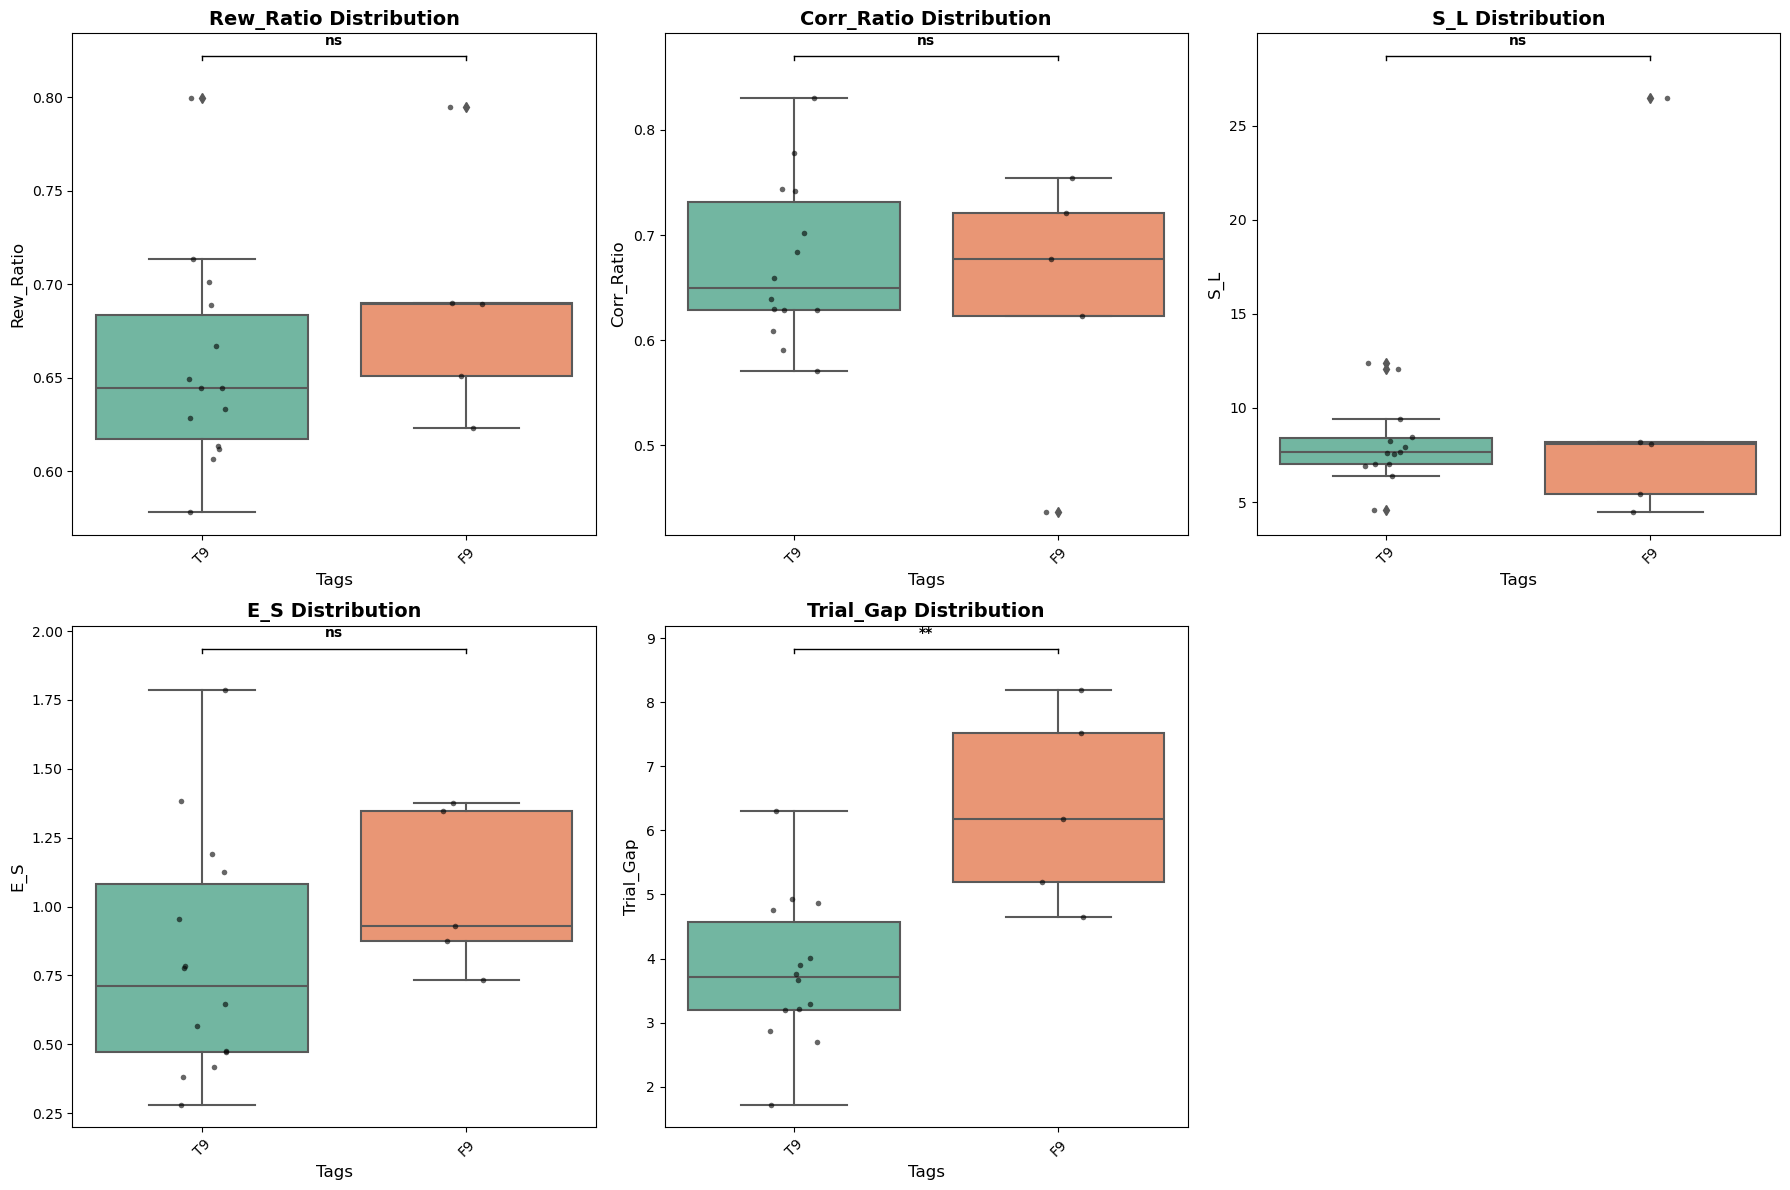


描述性统计：
     Rew_Ratio                                                             \
         count      mean       std       min      25%       50%       75%   
Tags                                                                        
F9         5.0  0.689687  0.065082  0.623214  0.65082  0.689732  0.690037   
T9        14.0  0.655886  0.056168  0.578261  0.61740  0.644583  0.683386   

               Corr_Ratio            ...       E_S           Trial_Gap  \
           max      count      mean  ...       75%       max     count   
Tags                                 ...                                 
F9    0.794631        5.0  0.642427  ...  1.346154  1.375000       5.0   
T9    0.799807       14.0  0.673976  ...  1.082386  1.785714      14.0   

                                                                           
          mean       std       min      25%       50%       75%       max  
Tags                                                                       
F9    6

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# 从剪贴板读取数据
df = pd.read_clipboard()

# 查看数据结构
print("数据前几行：")
print(df.head())
print("\n数据信息：")
print(df.info())

# 检查数据列名
print("\n数据列名：")
print(df.columns.tolist())

# 定义所有要分析的特征列
feature_columns = ['Rew_Ratio', 'Corr_Ratio', 'S_L', 'E_S', 'Trial_Gap']

# 数据整理
df_melted = df.melt(id_vars=['Tags'], value_vars=feature_columns, 
                    var_name='Data_Type', value_name='Value')

# 统计检验 - 对每个数据类型，将每个组与'T9'进行比较
t_test_results = {}

for data_type in feature_columns:
    data_subset = df_melted[df_melted['Data_Type'] == data_type]
    T9_data = data_subset[data_subset['Tags'] == 'T9']['Value'].values
    
    # 获取所有唯一的标签（除了T9）
    other_tags = [tag for tag in data_subset['Tags'].unique() if tag != 'T9']
    
    results = {}
    for tag in other_tags:
        tag_data = data_subset[data_subset['Tags'] == tag]['Value'].values
        if len(T9_data) > 0 and len(tag_data) > 0:
            t_stat, p_value = stats.ttest_ind(T9_data, tag_data)
            results[tag] = p_value
    
    t_test_results[data_type] = results

print("\nT检验结果（与T9比较）：")
for data_type, tag_results in t_test_results.items():
    print(f"\n{data_type}:")
    for tag, p_val in tag_results.items():
        print(f"  {tag} vs T9: p-value = {p_val:.4f}")

# 创建图形 - 5个特征，使用2x3的布局
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# 设置颜色 - 使用seaborn默认调色板
unique_tags = df['Tags'].unique()
palette = sns.color_palette("Set2", len(unique_tags))



# 为每个特征绘制箱型图
for i, feature in enumerate(feature_columns):
    if i < len(axes):
        ax = axes[i]
        step_height = 0
        # 绘制箱型图
        sns.boxplot(data=df, x='Tags', y=feature, ax=ax, palette=palette)
        sns.stripplot(data=df, x='Tags', y=feature, ax=ax, color='black', alpha=0.6, size=4, jitter=True)
        
        # 标注显著性（与T9比较）
        if feature in t_test_results:
            y_max = df[feature].max()
            y_min = df[feature].min()
            y_range = y_max - y_min
            
            # 为每个非T9标签添加显著性标注
            x_positions = {}
            for j, tag in enumerate(unique_tags):
                x_positions[tag] = j
            
            T9_position = x_positions['T9']
            
            for tag, p_value in t_test_results[feature].items():
                if tag in x_positions:
                    tag_position = x_positions[tag]
                    mid_point = (T9_position + tag_position) / 2
                    
                    # 计算标注位置
                    significance_y = y_max + 0.1 * y_range + step_height*0.1*y_range
                    
                    # 添加显著性符号
                    if p_value < 0.001:
                        symbol = '***'
                    elif p_value < 0.01:
                        symbol = '**'
                    elif p_value < 0.05:
                        symbol = '*'
                    else:
                        symbol = 'ns'
                    
                    # 添加横线和标注
                    ax.plot([T9_position, tag_position], [significance_y , significance_y ], 'k-', lw=1)
                    ax.plot([T9_position, T9_position], [significance_y-0.01*y_range , significance_y ], 'k-', lw=1)
                    ax.plot([tag_position, tag_position], [significance_y-0.01*y_range , significance_y ], 'k-', lw=1)
                    ax.text(mid_point, significance_y + 0.02*y_range , symbol, 
                           ha='center', va='bottom', fontsize=10, fontweight='bold')
                step_height += 1      
        
        ax.set_title(f'{feature} Distribution', fontsize=14, fontweight='bold')
        ax.set_ylabel(feature, fontsize=12)
        ax.set_xlabel('Tags', fontsize=12)
        
        # 旋转x轴标签以避免重叠
        ax.tick_params(axis='x', rotation=45)

# 如果子图数量多于特征数量，隐藏多余的子图
for i in range(len(feature_columns), len(axes)):
    axes[i].set_visible(False)

# 调整布局
plt.tight_layout()

# 显示图形
plt.show()

# 显示描述性统计
print("\n描述性统计：")
desc_stats = df.groupby('Tags')[feature_columns].describe()
print(desc_stats)

# 创建显著性结果表格
print("\n显著性总结（与T9比较）:")
significance_summary = []
for feature in feature_columns:
    if feature in t_test_results:
        for tag, p_val in t_test_results[feature].items():
            if p_val < 0.001:
                sig_level = '***'
            elif p_val < 0.01:
                sig_level = '**'
            elif p_val < 0.05:
                sig_level = '*'
            else:
                sig_level = 'ns'
            significance_summary.append({
                'Feature': feature,
                'Comparison': f'{tag} vs T9',
                'p-value': f'{p_val:.4f}',
                'Significance': sig_level
            })

significance_df = pd.DataFrame(significance_summary)
print(significance_df)